In [ ]:
#pip install contextily
#pip install gmplot
# Install contextily for basemaps
#%pip install -q contextily


In [ ]:
import pandas as pd
import geopandas
from shapely.geometry import Point
import matplotlib.pyplot as plt
import plotly.express as px
import folium

places = [
    {
        "name_place": "Sleiman Skate Store",
        "address_place": "R. Itapura, 1302 - Tatuapé",
        "latitude": -23.5500965,
        "longitude": -46.568058,
        "cep_place": "03309-000"
    },
    {
        "name_place": "Balão Skatepark",
        "address_place": "Pr. Gen. Porto Carreiro - Jaguaré",
        "latitude": -23.5465929,
        "longitude": -46.7513887,
        "cep_place": "05331-040"
    },
    {
        "name_place": "Base in Box",
        "address_place": "R. Dr. Augusto de Miranda - Pompeia, 835",
        "latitude": -23.5306957,
        "longitude": -46.6918467,
        "cep_place": "05026-000"
    },
    {
        "name_place": "Bowl Arariba (SKATE PARK)",
        "address_place": "Dr Gabriel - Vila Prel",
        "latitude": -23.6434158,
        "longitude": -46.7496640,
        "cep_place": "05777-200"
    },
    {
        "name_place": "Bowl Ipasure",
        "address_place": "R. Luís de Pina - Veleiros",
        "latitude": -23.6869735,
        "longitude": -46.7151354,
        "cep_place": "04771-220"
    },
    {
        "name_place": "Bowldogz",
        "address_place": "Praça Durval Pereira, 53 - Vila Paulista",
        "latitude": -23.6374127,
        "longitude": -46.6635923,
        "cep_place": None
    },
    {
        "name_place": "Bowlhouse | Pista de Skate | Vila Mariana",
        "address_place": "R. Morgado de Mateus, 652 - Vila Mariana",
        "latitude": -23.5872599,
        "longitude": -46.6506880,
        "cep_place": "04015-051"
    },
    {
        "name_place": "Brasil Skate Camp",
        "address_place": "R. das Macieiras, 249 - Casa Verde Média",
        "latitude": -23.5054852,
        "longitude": -46.6705250,
        "cep_place": "02521-090"
    },
    {
        "name_place": "Carniça Skate Park",
        "address_place": "Av. Alcântara Machado - Mooca",
        "latitude": -23.5476707,
        "longitude": -46.6049065,
        "cep_place": "03101-001"
    },
    {
        "name_place": "CDC Arena Radical",
        "address_place": "Praça Augusto Rademaker Grunewald, 37 - Vila Olímpia",
        "latitude": -23.5972560,
        "longitude": -46.6927463,
        "cep_place": "04548-060"
    },
    {
        "name_place": "CENTRO DE ESPORTES RADICAIS",
        "address_place": "Av. Pres. Castelo Branco, 5700 - Bom Retiro",
        "latitude": -23.5198570,
        "longitude": -46.6462001,
        "cep_place": "01142-300"
    },
    {
        "name_place": "Chorão Skate Park",
        "address_place": "Av. Dr. Sebastião Medeiros, 2",
        "latitude": -23.7204565,
        "longitude": -46.6974121,
        "cep_place": "04809-070"
    },
    {
        "name_place": "Manifesto Skatepark",
        "address_place": "Rua Oliveira Alves, 782 - Ipiranga",
        "latitude": -23.5855520,
        "longitude": -46.6034270,
        "cep_place": None
    },
    {
        "name_place": "Mooca Skatepark",
        "address_place": "Rua Taquari, 635 - Mooca",
        "latitude": -23.5501507,
        "longitude": -46.5995220,
        "cep_place": "03166-000"
    },
    {
        "name_place": "Morrão Skate Park",
        "address_place": "Rua Dante, 34 - Cidade Líder",
        "latitude": -23.5524711,
        "longitude": -46.5040516,
        "cep_place": "03580-030"
    },
    {
        "name_place": "Myrna Skatepark - Chorão",
        "address_place": "Av. Antonio Carlos Benjamin dos Santos, 3156-3174",
        "latitude": -23.7657980,
        "longitude": -46.6996503,
        "cep_place": "04856-070"
    },
    {
        "name_place": "New Wave Skate Park",
        "address_place": "Rua José Zappi, 236 - Vila Prudente",
        "latitude": -23.5792449,
        "longitude": -46.5871144,
        "cep_place": "03128-140"
    }
]

df = pd.DataFrame(places)

print(df)

# Optional: save to CSV
#df.to_csv("skateparks_sp.csv", index=False, encoding="utf-8-sig")

# Optional: create a geometry column for mapping
#df["localization_place"] = list(zip(df["longitude"], df["latitude"]))

#print("\nDataFrame shape:", df.shape)
#print(df.head())

                                   name_place  \
0                         Sleiman Skate Store   
1                             Balão Skatepark   
2                                 Base in Box   
3                   Bowl Arariba (SKATE PARK)   
4                                Bowl Ipasure   
5                                    Bowldogz   
6   Bowlhouse | Pista de Skate | Vila Mariana   
7                           Brasil Skate Camp   
8                          Carniça Skate Park   
9                           CDC Arena Radical   
10                CENTRO DE ESPORTES RADICAIS   
11                          Chorão Skate Park   
12                        Manifesto Skatepark   
13                            Mooca Skatepark   
14                          Morrão Skate Park   
15                   Myrna Skatepark - Chorão   
16                        New Wave Skate Park   

                                        address_place   latitude  longitude  \
0                          R. Itapura,

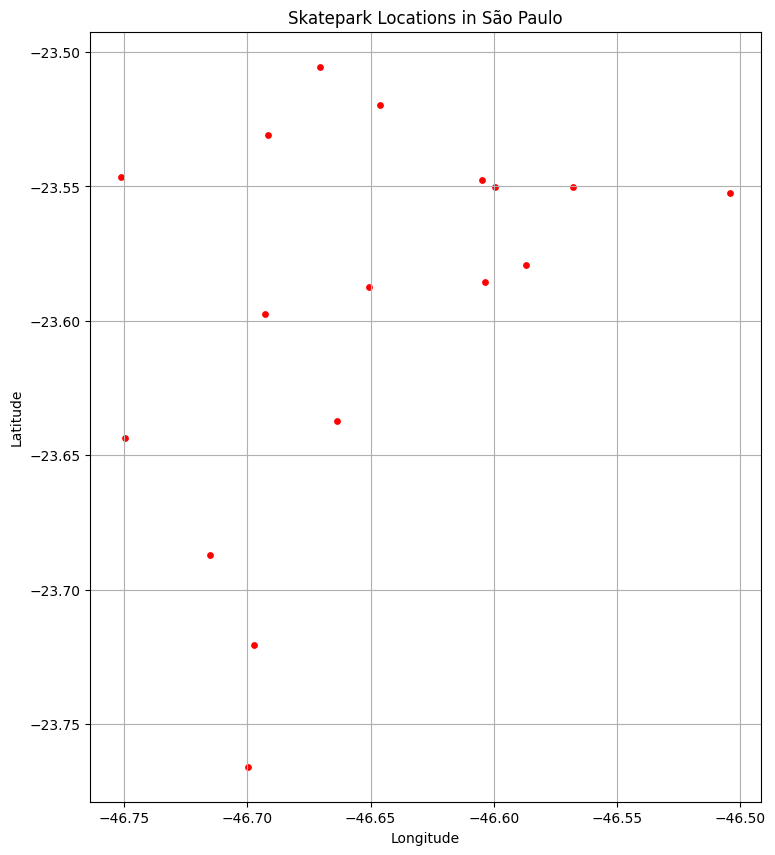

In [ ]:
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]

geodf = geopandas.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))
geodf.plot(ax=ax, marker='o', color='red', markersize=15)

plt.title('SKATEPlace')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [22]:
fig = px.scatter_mapbox(df,
                        lat="latitude",
                        lon="longitude",
                        hover_name="name_place",
                        hover_data=["address_place"],
                        zoom=9,
                        height=500)

fig.update_layout(mapbox_style="open-street-map",
                  title_text='SKATEPlace')

fig.show()

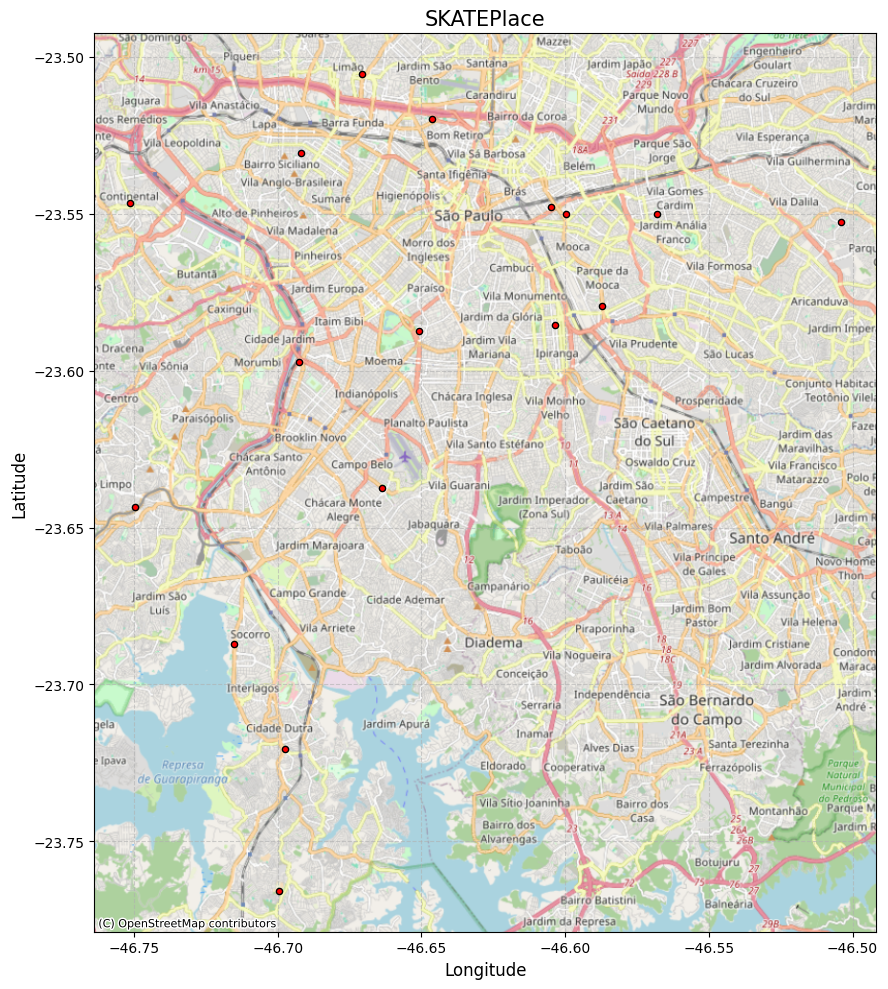

In [21]:
import contextily as cx

fig, ax = plt.subplots(figsize=(10, 10))
geodf.plot(ax=ax, marker='o', color='red', markersize=20, edgecolor='black', zorder=2)

cx.add_basemap(ax, crs=geodf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

plt.title('SKATEPlace', fontsize=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:

mean_latitude = df['latitude'].mean()
mean_longitude = df['longitude'].mean()

m = folium.Map(location=[mean_latitude, mean_longitude], zoom_start=11)

for index, row in df.iterrows():
    popup_text = f"<b>{row['name_place']}</b><br>{row['address_place']}"
    tooltip_text = f"{row['name_place']} - {row['address_place']}"
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=popup_text,
        tooltip=tooltip_text
    ).add_to(m)

m